# Import Modules

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from utils import *

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Data Processing

## 22. Statlog Heart Disease

In [2]:
df_statlog: pd.DataFrame = pd.read_csv('data/raw/22-statlog.csv')
df_statlog.head()

,age,sex,chest-pain,rest-bp,serum-chol,fasting-blood-sugar,electrocardiographic,max-heart-rate,angina,oldpeak,slope,major-vessels,thal,heart-disease
0,70.0,1.0,4.0,130.0,322.0,0.0,2.0,109.0,0.0,2.4,2.0,3.0,3.0,2
1,67.0,0.0,3.0,115.0,564.0,0.0,2.0,160.0,0.0,1.6,2.0,0.0,7.0,1
2,57.0,1.0,2.0,124.0,261.0,0.0,0.0,141.0,0.0,0.3,1.0,0.0,7.0,2
3,64.0,1.0,4.0,128.0,263.0,0.0,0.0,105.0,1.0,0.2,2.0,1.0,7.0,1
4,74.0,0.0,2.0,120.0,269.0,0.0,2.0,121.0,1.0,0.2,1.0,1.0,3.0,1


In [3]:
df_statlog.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   270 non-null    float64
 1   sex                   270 non-null    float64
 2   chest-pain            270 non-null    float64
 3   rest-bp               270 non-null    float64
 4   serum-chol            270 non-null    float64
 5   fasting-blood-sugar   270 non-null    float64
 6   electrocardiographic  270 non-null    float64
 7   max-heart-rate        270 non-null    float64
 8   angina                270 non-null    float64
 9   oldpeak               270 non-null    float64
 10  slope                 270 non-null    float64
 11  major-vessels         270 non-null    float64
 12  thal                  270 non-null    float64
 13  heart-disease         270 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 29.7 KB


In [4]:
df_statlog.isnull().sum()

age                     0
sex                     0
chest-pain              0
rest-bp                 0
serum-chol              0
fasting-blood-sugar     0
electrocardiographic    0
max-heart-rate          0
angina                  0
oldpeak                 0
slope                   0
major-vessels           0
thal                    0
heart-disease           0
dtype: int64

In [5]:
df_preprocessed_statlog, scaler_statlog = preprocess_statlog(df_statlog)
df_preprocessed_statlog.head()

,age,sex,cp_type,sbp,chol,fbs,ecg,hr,angina,oldpeak,slope,mv,thal,target
0,0.854167,1,4,0.339623,0.447489,0,2,0.290076,0,0.387097,2,3,0,1
1,0.791667,0,3,0.198113,1.000000,0,2,0.679389,0,0.258065,2,0,2,0
2,0.583333,1,2,0.283019,0.308219,0,0,0.534351,0,0.048387,1,0,2,1
3,0.729167,1,4,0.320755,0.312785,0,0,0.259542,1,0.032258,2,1,2,0
4,0.937500,0,2,0.245283,0.326484,0,2,0.381679,1,0.032258,1,1,0,0


<b>Statlog Column Definition</b>
1. age (Numeric, scaled)      - Patient Age [0, 1]
2. sex (Categorical)          - Patient Sex
    - 0 - female
    - 1 - male
3. cp_type (Categorical)      - Chest Pain Type
    - 1 - typical angina
    - 2 - atypical angina
    - 3 - nonanginal
    - 4 - asymptomatic
4. sbp (Numeric, scaled)      - Systolic Blood Pressure [0, 1]
5. chol (Numeric, scaled)     - Cholesterol [0, 1]
6. fbs (Categorical)          - Fasting Blood Sugar > 120 mg/dL
    - 0 - false
    - 1 - true
7. ecg (Categorical)          - Resting Electrocardiographic Result
    - 0 - normal
    - 1 - ST-T wave abnormality
    - 2 - left ventricular hypertrophy
8. hr (Numeric, scaled)       - Heart Rate [0, 1]
9. angina (Categorical)       - Exercise Induced Angina
    - 0 - no
    - 1 - yes
10. oldpeak (Numeric, scaled) - ST Depression [0, 1]
11. slope (Categorical)       - Slope of peak exercise ST segment
    - 1 - upsloping
    - 2 - flat
    - 3 - downsloping
12. mv (Numeric)              - Number of Major Vessels
13. thal (Categorical)        - Defect type
    - 0 - normal
    - 1 - fixed defect
    - 2 - reversible defect
14. target (Categorical)      - Disease Status
    - 0 - No Disease
    - 1 - Have Disease

In [6]:
df_preprocessed_statlog.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   age      270 non-null    float64
 1   sex      270 non-null    int32  
 2   cp_type  270 non-null    int32  
 3   sbp      270 non-null    float64
 4   chol     270 non-null    float64
 5   fbs      270 non-null    int32  
 6   ecg      270 non-null    int32  
 7   hr       270 non-null    float64
 8   angina   270 non-null    int32  
 9   oldpeak  270 non-null    float64
 10  slope    270 non-null    int32  
 11  mv       270 non-null    int32  
 12  thal     270 non-null    int64  
 13  target   270 non-null    int64  
dtypes: float64(5), int32(7), int64(2)
memory usage: 22.3 KB


In [7]:
statlog_categorical_cols = ["sex", "cp_type", "fbs", "ecg", "angina", "slope", "thal", "target"]
statlog_numerical_cols = df_preprocessed_statlog.columns.difference(statlog_categorical_cols)

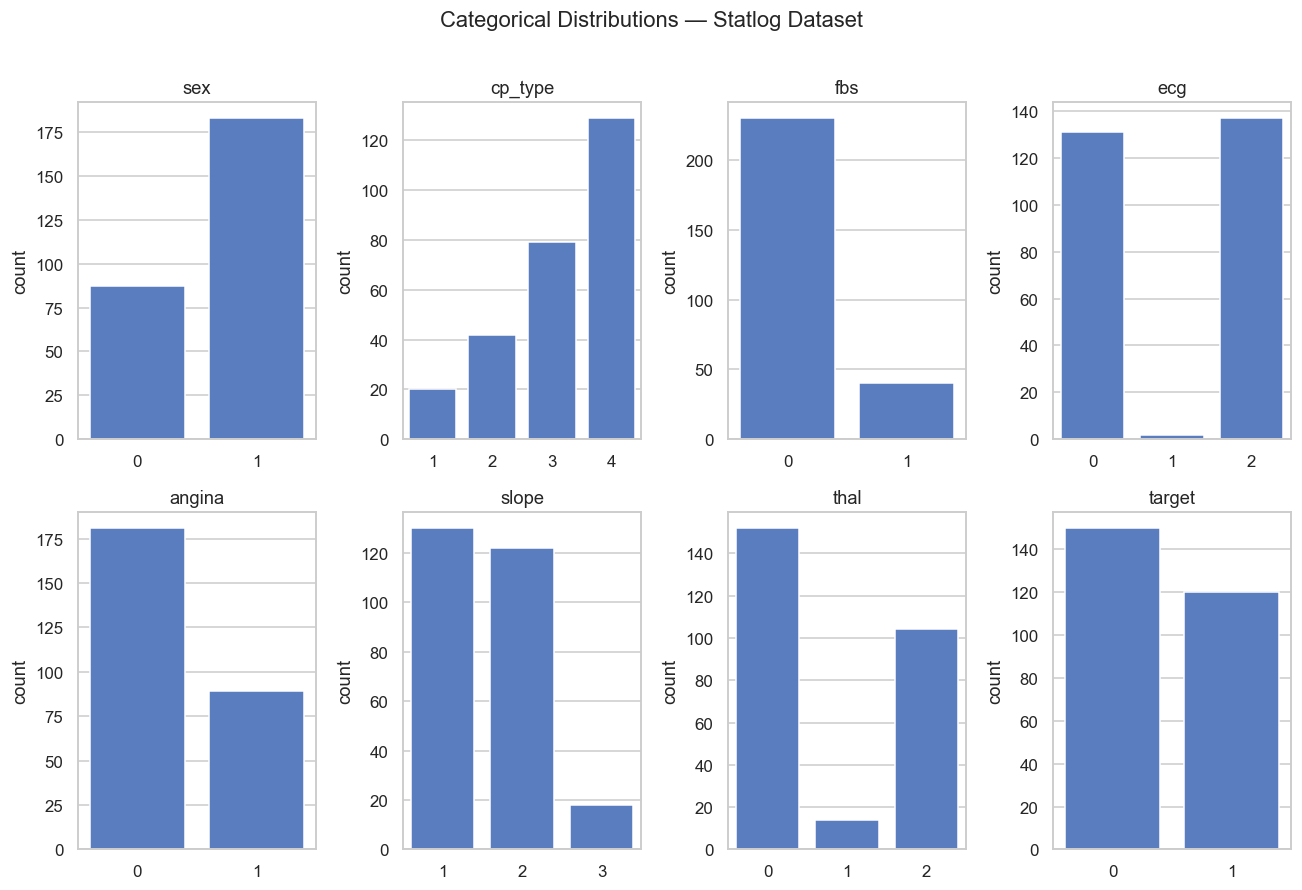

In [8]:
plot_categorical_distributions(df_preprocessed_statlog, statlog_categorical_cols)

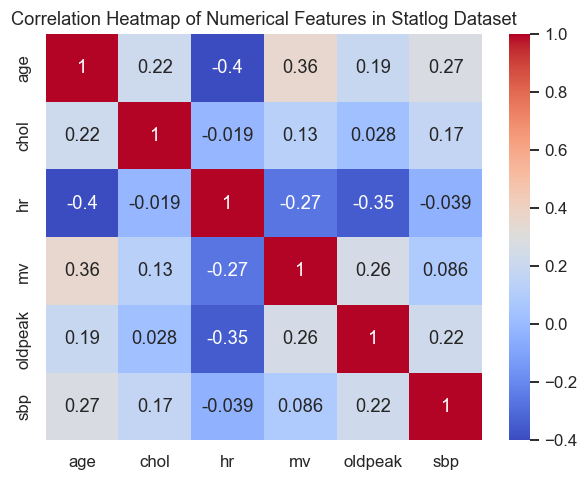

In [9]:
plot_numerical_heatmap(df_preprocessed_statlog, statlog_numerical_cols)

In [10]:
set_preprocessed(df_preprocessed_statlog, '22-statlog-preprocessed', scaler_statlog, '22-scaler_statlog')

## 23. Coronary Heart Disease

In [11]:
df_chd = pd.read_csv('data/raw/23-chd.csv')
df_chd.head()

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
0,160,12.00,5.73,23.11,Present,49,25.30,97.20,52,1
1,144,0.01,4.41,28.61,Absent,55,28.87,2.06,63,1
2,118,0.08,3.48,32.28,Present,52,29.14,3.81,46,0
3,170,7.50,6.41,38.03,Present,51,31.99,24.26,58,1
4,134,13.60,3.50,27.78,Present,60,25.99,57.34,49,1


In [12]:
df_chd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sbp        462 non-null    int64  
 1   tobacco    462 non-null    float64
 2   ldl        462 non-null    float64
 3   adiposity  462 non-null    float64
 4   famhist    462 non-null    object 
 5   typea      462 non-null    int64  
 6   obesity    462 non-null    float64
 7   alcohol    462 non-null    float64
 8   age        462 non-null    int64  
 9   chd        462 non-null    int64  
dtypes: float64(5), int64(4), object(1)
memory usage: 36.2+ KB


In [13]:
df_chd.isnull().sum()

sbp          0
tobacco      0
ldl          0
adiposity    0
famhist      0
typea        0
obesity      0
alcohol      0
age          0
chd          0
dtype: int64

In [14]:
df_preprocessed_chd, scaler_chd = preprocess_chd(df_chd)
df_preprocessed_chd.head()

,sbp,tobacco,ldl,adiposity,famhist,typea,bmi,alcohol,age,target
0,0.504274,0.384615,0.331010,0.457902,1,0.553846,0.332497,0.660371,0.755102,1
1,0.367521,0.000321,0.239024,0.611748,0,0.646154,0.444479,0.013996,0.979592,1
2,0.145299,0.002564,0.174216,0.714406,1,0.600000,0.452949,0.025885,0.632653,0
3,0.589744,0.240385,0.378397,0.875245,1,0.584615,0.542346,0.164821,0.877551,1
4,0.282051,0.435897,0.175610,0.588531,1,0.723077,0.354141,0.389565,0.693878,1


<b>Coronary Heart Disease (CHD) Column Definition</b>
1. sbp (Numeric, scaled)      - Systolic Blood Pressure [0, 1]
2. tobacco (Numeric, scaled)  - Yearly Tobacco Use (kg) [0, 1]
3. ldl (Numeric, scaled)      - Low Density Lipoprotein [0, 1]
4. adiposity (Numeric, scaled) - Adiposity Measure [0, 1]
5. famhist (Categorical)      - Family History of Coronary Heart Disease
    - 0 - Absent
    - 1 - Present
6. typea (Numeric, scaled)    - Type A Personality Score [0, 1]
7. bmi (Numeric, scaled)  - Body Mass Index [0, 1]
8. alcohol (Numeric, scaled)  - Yearly Alcohol Consumption (liters) [0, 1]
9. age (Numeric, scaled)      - Patient Age [0, 1]
10. target (Categorical)     - Disease Status
    - 0 - No Disease
    - 1 - Have Disease

In [15]:
df_preprocessed_chd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sbp        462 non-null    float64
 1   tobacco    462 non-null    float64
 2   ldl        462 non-null    float64
 3   adiposity  462 non-null    float64
 4   famhist    462 non-null    int64  
 5   typea      462 non-null    float64
 6   bmi        462 non-null    float64
 7   alcohol    462 non-null    float64
 8   age        462 non-null    float64
 9   target     462 non-null    int64  
dtypes: float64(8), int64(2)
memory usage: 36.2 KB


In [16]:
chd_categorical_cols = ["famhist", "target"]
chd_numerical_cols = df_preprocessed_chd.columns.difference(chd_categorical_cols)

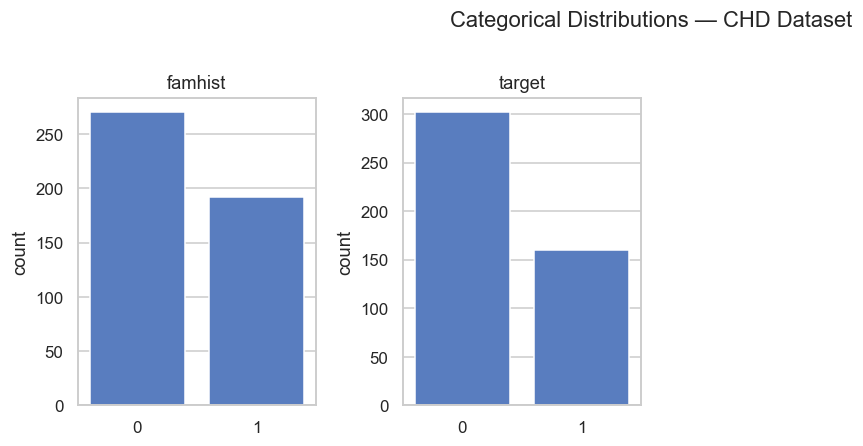

In [17]:
plot_categorical_distributions(df_preprocessed_chd, chd_categorical_cols)

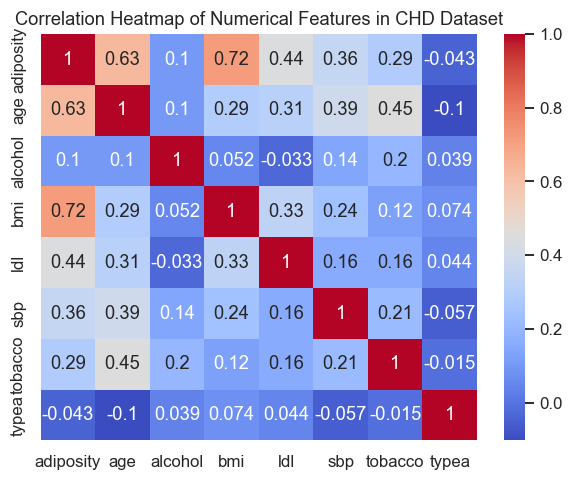

In [18]:
plot_numerical_heatmap(df_preprocessed_chd, chd_numerical_cols)

In [19]:
set_preprocessed(df_preprocessed_chd, '23-chd-preprocessed', scaler_chd, '23-chd-scaler')

## 24. Framingham

In [20]:
df_framingham = pd.read_csv('data/raw/24-framingham.csv')
df_framingham.head()

,Sex,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,male,39,4.0,No,0.0,0.0,0,0,No,195.0,106.0,70.0,26.97,80.0,77.0,0
1,female,46,2.0,No,0.0,0.0,0,0,No,250.0,121.0,81.0,28.73,95.0,76.0,0
2,male,48,1.0,Yes,20.0,0.0,0,0,No,245.0,127.5,80.0,25.34,75.0,70.0,0
3,female,61,3.0,Yes,30.0,0.0,0,1,No,225.0,150.0,95.0,28.58,65.0,103.0,1
4,female,46,3.0,Yes,23.0,0.0,0,0,No,285.0,130.0,84.0,23.10,85.0,85.0,0


In [21]:
df_framingham.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Sex              4240 non-null   object 
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   object 
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   object 
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(4), object(3)
memory usage: 530.1+ KB


In [22]:
df_framingham.isnull().sum()

Sex                  0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [23]:
df_preprocessed_framingham, scaler_framingham = preprocess_framingham(df_framingham)
df_preprocessed_framingham.head()

,sex,age,edu,smoking_status,num_cigs_per_day,bp_status,stroke_status,hypertension_status,diabetes_status,chol,sbp,dbp,bmi,hr,glucose_level,target
0,1,0.184211,4,0,0.000000,0,0,0,0,0.149406,0.106383,0.232804,0.277024,0.363636,0.104520,0
1,0,0.368421,2,0,0.000000,0,0,0,0,0.242784,0.177305,0.349206,0.319680,0.515152,0.101695,0
2,1,0.421053,1,1,0.285714,0,0,0,0,0.234295,0.208038,0.338624,0.237518,0.313131,0.084746,0
3,0,0.763158,3,1,0.428571,0,0,1,0,0.200340,0.314421,0.497354,0.316045,0.212121,0.177966,1
4,0,0.368421,3,1,0.328571,0,0,0,0,0.302207,0.219858,0.380952,0.183228,0.414141,0.127119,0


<b>Framingham Column Definition</b>
1. sex (Categorical)              - Patient Sex
    - 0 - female
    - 1 - male
2. age (Numeric, scaled)          - Patient Age [0, 1]
3. edu (Categorical)              - Education Level
    - 1 - Some high school
    - 2 - High school or GED
    - 3 - Some college or vocational school
    - 4 - College
4. smoking_status (Categorical)   - Current Smoker Status
    - 0 - No
    - 1 - Yes
5. num_cigs_per_day (Numeric, scaled) - Cigarettes per Day [0, 1]
6. bp_status (Categorical)        - On Blood Pressure Medication
    - 0 - No
    - 1 - Yes
7. stroke_status (Categorical)    - Prevalent Stroke
    - 0 - No
    - 1 - Yes
8. hypertension_status (Categorical) - Prevalent Hypertension
    - 0 - No
    - 1 - Yes
9. diabetes_status (Categorical)  - Diabetes Status
    - 0 - No
    - 1 - Yes
10. chol (Numeric, scaled)        - Total Cholesterol [0, 1]
11. sbp (Numeric, scaled)         - Systolic Blood Pressure [0, 1]
12. dbp (Numeric, scaled)         - Diastolic Blood Pressure [0, 1]
13. bmi (Numeric, scaled)         - Body Mass Index [0, 1]
14. hr (Numeric, scaled)          - Heart Rate [0, 1]
15. glucose_level (Numeric, scaled) - Glucose Level [0, 1]
16. target (Categorical)          - Disease Status
    - 0 - No Disease
    - 1 - Have Disease

In [24]:
df_preprocessed_framingham.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sex                  4240 non-null   int64  
 1   age                  4240 non-null   float64
 2   edu                  4240 non-null   int32  
 3   smoking_status       4240 non-null   int32  
 4   num_cigs_per_day     4240 non-null   float64
 5   bp_status            4240 non-null   int32  
 6   stroke_status        4240 non-null   int32  
 7   hypertension_status  4240 non-null   int32  
 8   diabetes_status      4240 non-null   int64  
 9   chol                 4240 non-null   float64
 10  sbp                  4240 non-null   float64
 11  dbp                  4240 non-null   float64
 12  bmi                  4240 non-null   float64
 13  hr                   4240 non-null   float64
 14  glucose_level        4240 non-null   float64
 15  target               4240 non-null   i

In [25]:
df_preprocessed_framingham.isnull().sum()

sex                    0
age                    0
edu                    0
smoking_status         0
num_cigs_per_day       0
bp_status              0
stroke_status          0
hypertension_status    0
diabetes_status        0
chol                   0
sbp                    0
dbp                    0
bmi                    0
hr                     0
glucose_level          0
target                 0
dtype: int64

In [26]:
framingham_categorical_cols = ['sex', 'edu', 'smoking_status', 'bp_status', 'stroke_status', 'hypertension_status', 'diabetes_status', 'target']
framingham_numerical_cols = df_preprocessed_framingham.columns.difference(framingham_categorical_cols)

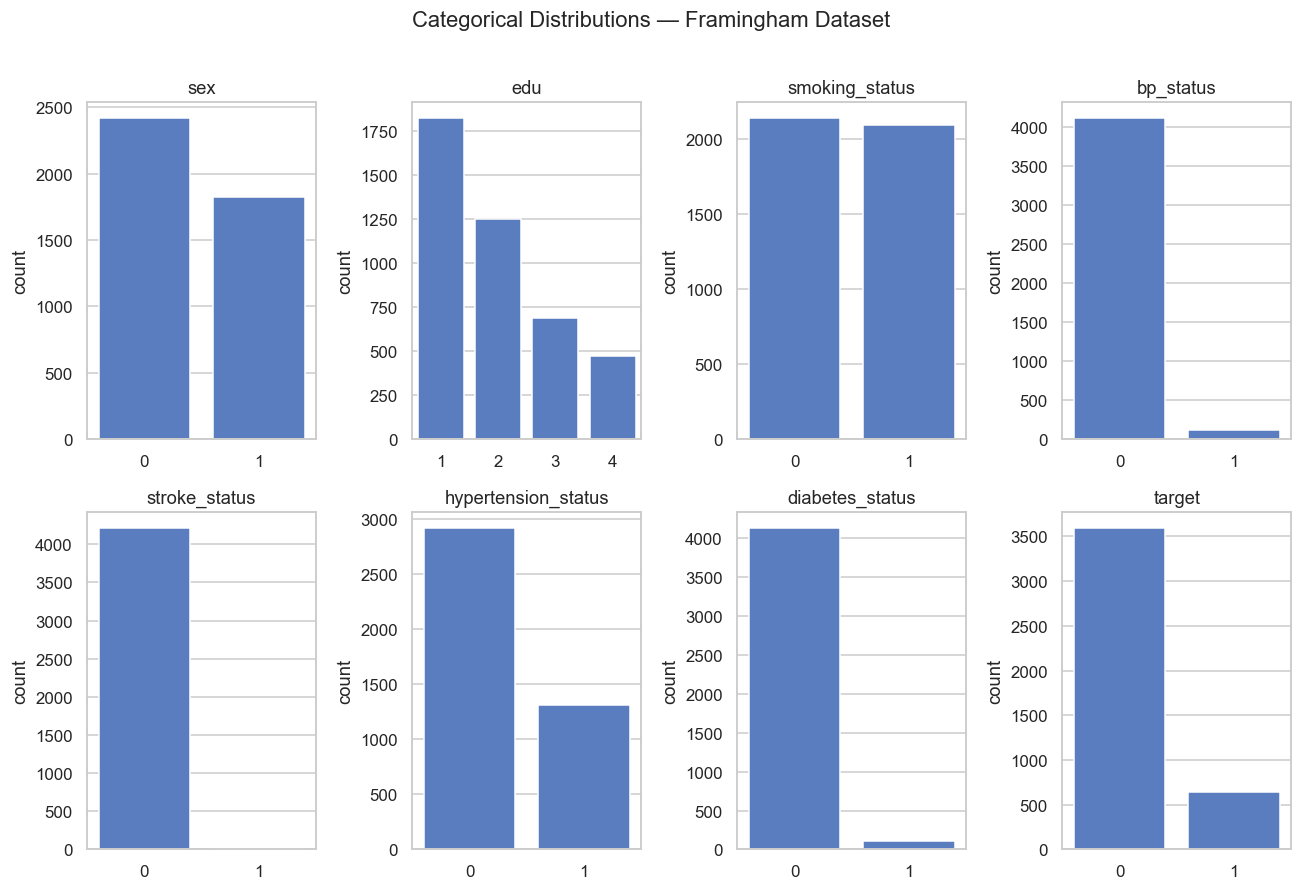

In [27]:
plot_categorical_distributions(df_preprocessed_framingham, framingham_categorical_cols)

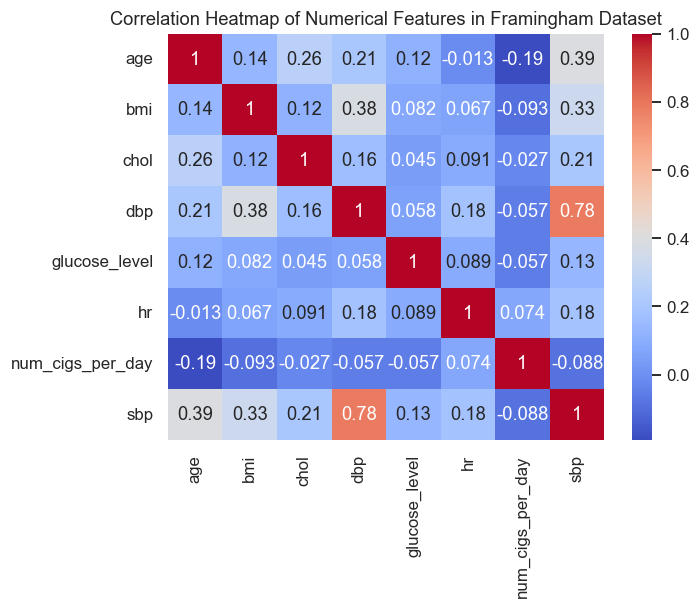

In [28]:
plot_numerical_heatmap(df_preprocessed_framingham, framingham_numerical_cols)

In [29]:
set_preprocessed(df_preprocessed_framingham, '24-framingham-preprocessed', scaler_framingham, '24-framingham-scaler')

## 25. Heart Disease

In [30]:
df_heart = pd.read_csv('data/raw/25-heart.csv')
df_heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [31]:
df_heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [32]:
df_preprocessed_heart, heart_scaler = preprocess_heart(df_heart)
df_preprocessed_heart.head()

,age,sex,cp_type,sbp,chol,fbs,ecg,hr,angina,oldpeak,slope,mv,thal,target
0,0.479167,1,1,0.292453,0.196347,0,1,0.740458,0,0.161290,3,2,3,0
1,0.500000,1,1,0.433962,0.175799,1,0,0.641221,1,0.500000,1,0,3,0
2,0.854167,1,1,0.481132,0.109589,0,1,0.412214,1,0.419355,1,0,3,0
3,0.666667,1,1,0.509434,0.175799,0,1,0.687023,0,0.000000,3,1,3,0
4,0.687500,0,1,0.415094,0.383562,1,1,0.267176,0,0.306452,2,3,2,0


<b>Heart Disease Column Definition</b>
1. age (Numeric)            - Patient Age
2. sex (Categorical)        - Patient Sex
    - 0 - female
    - 1 - male
3. cp_type (Categorical)    - Chest Pain Type
    - 1 - typical angina
    - 2 - atypical angina
    - 3 - nonanginal
    - 4 - asymptomatic
4. sbp (Numeric)            - Systolic Blood Pressure
5. chol (Numeric)           - Cholesterol
6. fbs (Categorical)        - Fasting Blood Sugar > 120 mg/dL
    - 0 - false
    - 1 - true
7. ecg (Categorical)        - Resting Electrocardiographic Result
    - 0 - normal
    - 1 - ST-T wave abnormality
    - 2 - left ventricular hypertrophy
8. hr (Numeric)             - Heart Rate
9. angina (Categorical)     - Exercise Induced Angina
    - 0 - no
    - 1 - yes
10. oldpeak (Numeric)       - ST Depression induced by exercise relative to the rest
11. slope (Categorical)     - Slope of peak exercise ST segment
    - 1 - upsloping
    - 2 - flat
    - 3 - downsloping
12. mv (Numeric)            - Number of Major Vessels
13. thal (Categorical)      - Defect type
    - 0 - normal
    - 1 - fixed defect
    - 2 - reversible defect
    - 3 - unknown
14. target (Categorical)    - Disease Status
    - 0 - No Disease
    - 1 - Have Disease

In [33]:
df_preprocessed_heart.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   age      302 non-null    float64
 1   sex      302 non-null    int64  
 2   cp_type  302 non-null    int64  
 3   sbp      302 non-null    float64
 4   chol     302 non-null    float64
 5   fbs      302 non-null    int64  
 6   ecg      302 non-null    int64  
 7   hr       302 non-null    float64
 8   angina   302 non-null    int64  
 9   oldpeak  302 non-null    float64
 10  slope    302 non-null    int64  
 11  mv       302 non-null    int64  
 12  thal     302 non-null    int64  
 13  target   302 non-null    int64  
dtypes: float64(5), int64(9)
memory usage: 35.4 KB


In [34]:
df_preprocessed_heart.isnull().sum()

age        0
sex        0
cp_type    0
sbp        0
chol       0
fbs        0
ecg        0
hr         0
angina     0
oldpeak    0
slope      0
mv         0
thal       0
target     0
dtype: int64

In [35]:
heart_categorical_cols = ["sex", "cp_type", "fbs", "ecg", "angina", "slope", "thal", "target"]
heart_numerical_cols = df_preprocessed_heart.columns.difference(heart_categorical_cols)

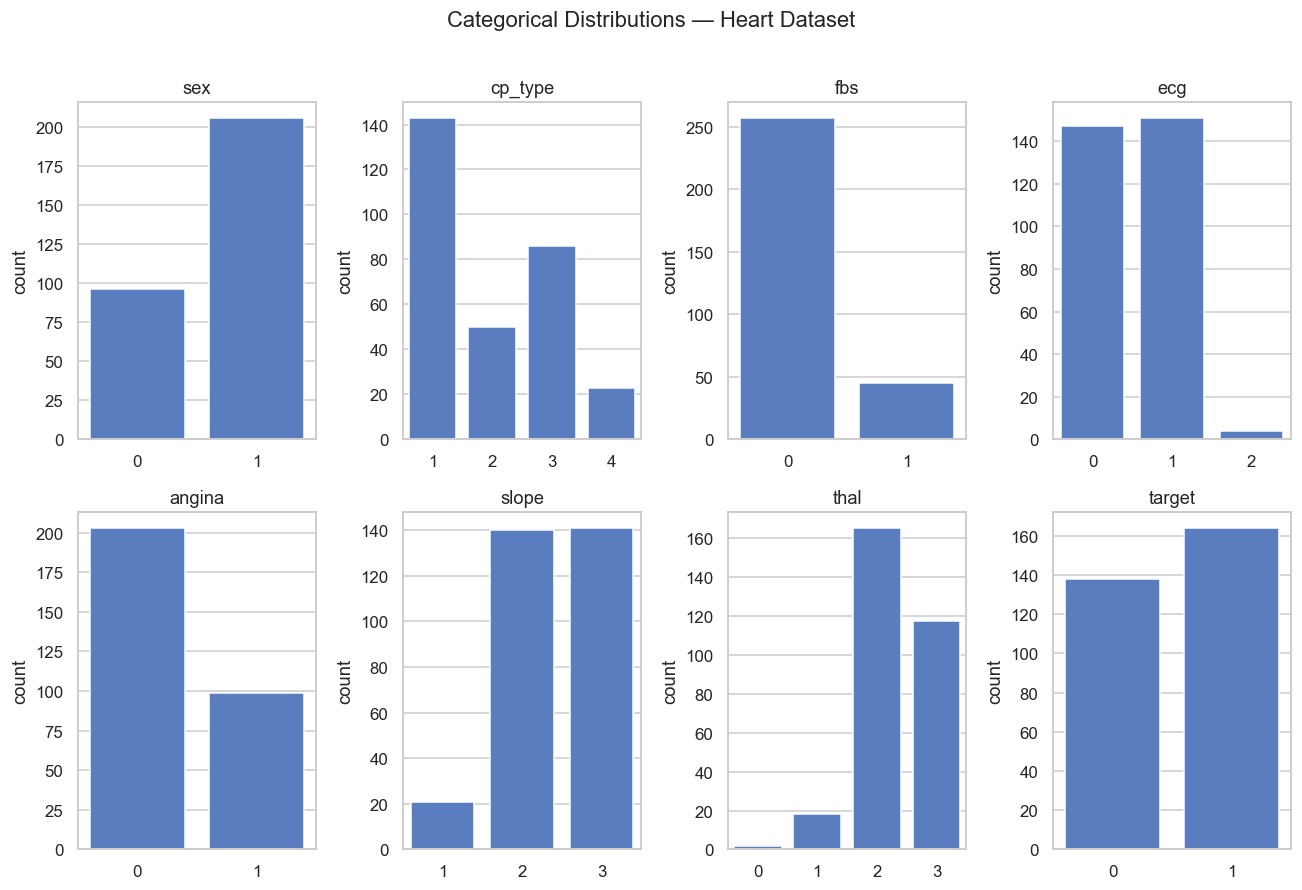

In [36]:
plot_categorical_distributions(df_preprocessed_heart, heart_categorical_cols)

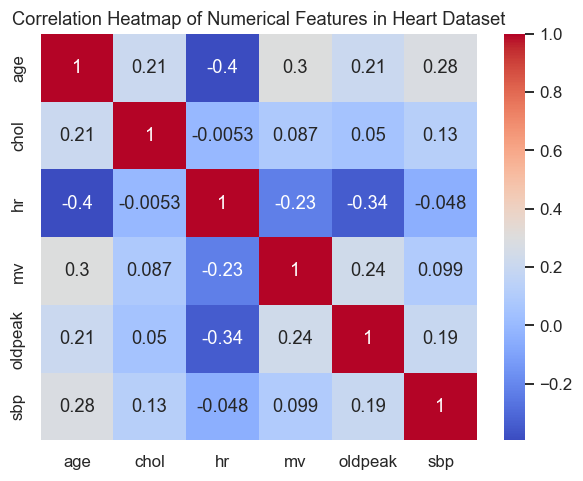

In [37]:
plot_numerical_heatmap(df_preprocessed_heart, heart_numerical_cols)

In [38]:
set_preprocessed(df_preprocessed_heart, '25-heart-preprocessed', heart_scaler, '25-heart-scaler')

## 26. Stroke

In [39]:
df_stroke = pd.read_csv('data/raw/26-stroke.csv')
df_stroke.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [40]:
df_stroke["smoking_status"].value_counts()

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

In [41]:
df_stroke.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [42]:
df_stroke.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [43]:
df_preprocessed_stroke, scaler_stroke = preprocess_stroke(df_stroke)
df_preprocessed_stroke.head()

,sex,age,hypertension_status,heart_disease_status,marital_status,work_type,residence_type,glucose_level,bmi,smoking_status,target
0,1,0.816895,0,1,1,0,1,0.801265,0.301260,0,1
1,0,0.743652,0,0,1,1,0,0.679023,0.212996,1,1
2,1,0.975586,0,1,1,0,0,0.234512,0.254296,1,1
3,0,0.597168,0,0,1,0,1,0.536008,0.276060,2,1
4,0,0.963379,1,0,1,1,0,0.549349,0.156930,1,1


<b>Stroke Column Description</b>
1. sex (Categorical) — Patient Sex
   - 0 = Female
   - 1 = Male
2. age (Numeric, scaled) — Patient Age [0, 1]
3. hypertension_status (Categorical) — Hypertension
   - 0 = No
   - 1 = Yes
4. heart_disease_status (Categorical) — Heart Disease
   - 0 = No
   - 1 = Yes
5. marital_status (Categorical) — Ever Married
   - 0 = No
   - 1 = Yes
6. work_type (Categorical) — Type of Work
   - 0 = Private
   - 1 = Self-employed
   - 2 = Government Job
   - 3 = Children
   - 4 = Never Worked
7. residence_type (Categorical) — Residence Type
   - 0 = Rural
   - 1 = Urban
8. glucose_level (Numeric, scaled) — Average Glucose Level [0, 1]
9. bmi (Numeric, scaled) — Body Mass Index [0, 1]
10. smoking_status (Categorical) — Smoking Status
    - 0 = Formerly Smoked
    - 1 = Never Smoked
    - 2 = Smokes
    - 3 = Unknown
11. target (Categorical) — Disease Status
    - 0 = No Stroke
    - 1 = Had Stroke

In [44]:
df_preprocessed_stroke.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5109 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sex                   5109 non-null   int32  
 1   age                   5109 non-null   float64
 2   hypertension_status   5109 non-null   int64  
 3   heart_disease_status  5109 non-null   int64  
 4   marital_status        5109 non-null   int64  
 5   work_type             5109 non-null   int64  
 6   residence_type        5109 non-null   int64  
 7   glucose_level         5109 non-null   float64
 8   bmi                   5109 non-null   float64
 9   smoking_status        5109 non-null   int64  
 10  target                5109 non-null   int64  
dtypes: float64(3), int32(1), int64(7)
memory usage: 459.0 KB


In [45]:
stroke_categorical_cols = ["sex", "hypertension_status", "heart_disease_status", "marital_status", "work_type", "residence_type", "smoking_status", "target"]
stroke_numerical_cols = df_preprocessed_stroke.columns.difference(stroke_categorical_cols)

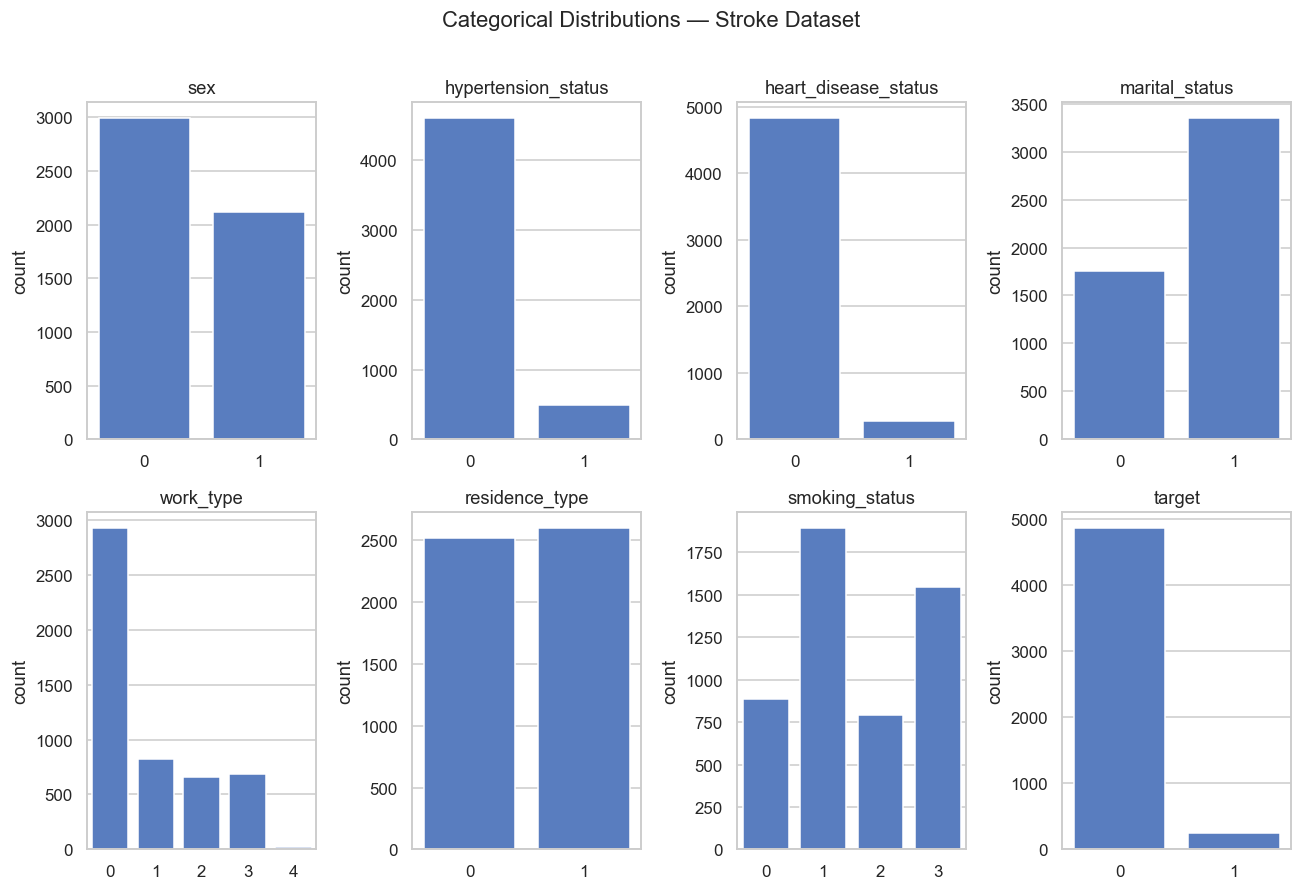

In [46]:
plot_categorical_distributions(df_preprocessed_stroke, stroke_categorical_cols)

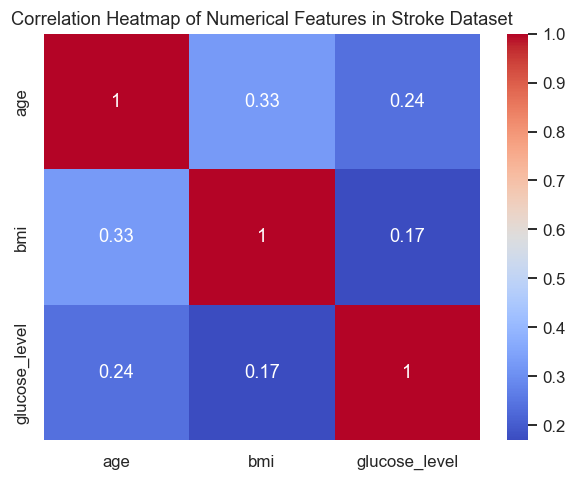

In [47]:
plot_numerical_heatmap(df_preprocessed_stroke, stroke_numerical_cols)

In [48]:
set_preprocessed(df_preprocessed_stroke, '26-stroke-preprocessed', scaler_stroke, '26-stroke-scaler')

## Concatenation

### Load Processed Datasets

In [49]:
df_preprocessed_statlog, scaler_statlog = get_preprocessed('22-statlog-preprocessed', '22-scaler_statlog')
df_preprocessed_chd, scaler_chd = get_preprocessed('23-chd-preprocessed', '23-chd-scaler')
df_preprocessed_framingham, scaler_framingham = get_preprocessed('24-framingham-preprocessed', '24-framingham-scaler')
df_preprocessed_heart, scaler_heart = get_preprocessed('25-heart-preprocessed', '25-heart-scaler')
df_preprocessed_stroke, scaler_stroke = get_preprocessed('26-stroke-preprocessed', '26-stroke-scaler')

### 22 & 23

In [50]:
df_statlog_chd_union = combine_datasets_union(df_preprocessed_statlog, df_preprocessed_chd, 'Statlog-CHD-Union')
df_statlog_chd_union.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 21 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        732 non-null    float64
 1   sex        270 non-null    float64
 2   cp_type    270 non-null    float64
 3   sbp        732 non-null    float64
 4   chol       270 non-null    float64
 5   fbs        270 non-null    float64
 6   ecg        270 non-null    float64
 7   hr         270 non-null    float64
 8   angina     270 non-null    float64
 9   oldpeak    270 non-null    float64
 10  slope      270 non-null    float64
 11  mv         270 non-null    float64
 12  thal       270 non-null    float64
 13  target     732 non-null    int64  
 14  tobacco    462 non-null    float64
 15  ldl        462 non-null    float64
 16  adiposity  462 non-null    float64
 17  famhist    462 non-null    float64
 18  typea      462 non-null    float64
 19  bmi        462 non-null    float64
 20  alcohol   

In [51]:
df_statlog_chd_intersection = combine_datasets_intersection(df_preprocessed_statlog, df_preprocessed_chd, 'Statlog-CHD-Intersection')
df_statlog_chd_intersection.info()

<class 'pandas.core.frame.DataFrame'>
Index: 657 entries, 0 to 729
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     657 non-null    float64
 1   sbp     657 non-null    float64
 2   target  657 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 20.5 KB


In [52]:
set_combined(df_statlog_chd_union)
set_combined(df_statlog_chd_intersection)

### 22 & 24

In [53]:
df_statlog_framingham_union = combine_datasets_union(df_preprocessed_statlog, df_preprocessed_framingham, 'Statlog-Framingham-Union')
df_statlog_framingham_union.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4510 entries, 0 to 4509
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  4510 non-null   float64
 1   sex                  4510 non-null   int64  
 2   cp_type              270 non-null    float64
 3   sbp                  4510 non-null   float64
 4   chol                 4510 non-null   float64
 5   fbs                  270 non-null    float64
 6   ecg                  270 non-null    float64
 7   hr                   4510 non-null   float64
 8   angina               270 non-null    float64
 9   oldpeak              270 non-null    float64
 10  slope                270 non-null    float64
 11  mv                   270 non-null    float64
 12  thal                 270 non-null    float64
 13  target               4510 non-null   int64  
 14  edu                  4240 non-null   float64
 15  smoking_status       4240 non-null   f

In [54]:
df_statlog_framingham_intersection = combine_datasets_intersection(df_preprocessed_statlog, df_preprocessed_framingham, 'Statlog-Framingham-Intersection')
df_statlog_framingham_intersection.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4509 entries, 0 to 4509
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     4509 non-null   float64
 1   sex     4509 non-null   int64  
 2   sbp     4509 non-null   float64
 3   chol    4509 non-null   float64
 4   hr      4509 non-null   float64
 5   target  4509 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 246.6 KB


In [55]:
set_combined(df_statlog_framingham_union)
set_combined(df_statlog_framingham_intersection)

### 22 & 25

In [56]:
df_statlog_heart_union = combine_datasets_union(df_preprocessed_statlog, df_preprocessed_heart, 'Statlog-Heart-Union')
df_statlog_heart_union.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   age      572 non-null    float64
 1   sex      572 non-null    int64  
 2   cp_type  572 non-null    int64  
 3   sbp      572 non-null    float64
 4   chol     572 non-null    float64
 5   fbs      572 non-null    int64  
 6   ecg      572 non-null    int64  
 7   hr       572 non-null    float64
 8   angina   572 non-null    int64  
 9   oldpeak  572 non-null    float64
 10  slope    572 non-null    int64  
 11  mv       572 non-null    int64  
 12  thal     572 non-null    int64  
 13  target   572 non-null    int64  
dtypes: float64(5), int64(9)
memory usage: 62.7 KB


In [57]:
df_statlog_heart_intersection = combine_datasets_intersection(df_preprocessed_statlog, df_preprocessed_heart, 'Statlog-Heart-Intersection')
df_statlog_heart_intersection.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   age      572 non-null    float64
 1   sex      572 non-null    int64  
 2   cp_type  572 non-null    int64  
 3   sbp      572 non-null    float64
 4   chol     572 non-null    float64
 5   fbs      572 non-null    int64  
 6   ecg      572 non-null    int64  
 7   hr       572 non-null    float64
 8   angina   572 non-null    int64  
 9   oldpeak  572 non-null    float64
 10  slope    572 non-null    int64  
 11  mv       572 non-null    int64  
 12  thal     572 non-null    int64  
 13  target   572 non-null    int64  
dtypes: float64(5), int64(9)
memory usage: 62.7 KB


In [58]:
set_combined(df_statlog_heart_union)
set_combined(df_statlog_heart_intersection)

### 22 & 26

In [59]:
df_statlog_stroke_union = combine_datasets_union(df_preprocessed_statlog, df_preprocessed_stroke, 'Statlog-Stroke-Union')
df_statlog_stroke_union.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5379 entries, 0 to 5378
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   5379 non-null   float64
 1   sex                   5379 non-null   int64  
 2   cp_type               270 non-null    float64
 3   sbp                   270 non-null    float64
 4   chol                  270 non-null    float64
 5   fbs                   270 non-null    float64
 6   ecg                   270 non-null    float64
 7   hr                    270 non-null    float64
 8   angina                270 non-null    float64
 9   oldpeak               270 non-null    float64
 10  slope                 270 non-null    float64
 11  mv                    270 non-null    float64
 12  thal                  270 non-null    float64
 13  target                5379 non-null   int64  
 14  hypertension_status   5109 non-null   float64
 15  heart_disease_status 

In [60]:
df_statlog_stroke_intersection = combine_datasets_intersection(df_preprocessed_statlog, df_preprocessed_stroke, 'Statlog-Stroke-Intersection')
df_statlog_stroke_intersection.info()

<class 'pandas.core.frame.DataFrame'>
Index: 390 entries, 0 to 4850
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     390 non-null    float64
 1   sex     390 non-null    int64  
 2   target  390 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 12.2 KB


In [61]:
set_combined(df_statlog_stroke_union)
set_combined(df_statlog_stroke_intersection)

### 23 & 24

In [62]:
df_chd_framingham_union = combine_datasets_union(df_preprocessed_chd, df_preprocessed_framingham, 'CHD-Framingham-Union')
df_chd_framingham_union.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4702 entries, 0 to 4701
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sbp                  4702 non-null   float64
 1   tobacco              462 non-null    float64
 2   ldl                  462 non-null    float64
 3   adiposity            462 non-null    float64
 4   famhist              462 non-null    float64
 5   typea                462 non-null    float64
 6   bmi                  4702 non-null   float64
 7   alcohol              462 non-null    float64
 8   age                  4702 non-null   float64
 9   target               4702 non-null   int64  
 10  sex                  4240 non-null   float64
 11  edu                  4240 non-null   float64
 12  smoking_status       4240 non-null   float64
 13  num_cigs_per_day     4240 non-null   float64
 14  bp_status            4240 non-null   float64
 15  stroke_status        4240 non-null   f

In [63]:
df_chd_framingham_intersection = combine_datasets_intersection(df_preprocessed_chd, df_preprocessed_framingham, 'CHD-Framingham-Intersection')
df_chd_framingham_intersection.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4697 entries, 0 to 4701
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sbp     4697 non-null   float64
 1   bmi     4697 non-null   float64
 2   age     4697 non-null   float64
 3   target  4697 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 183.5 KB


In [64]:
set_combined(df_chd_framingham_union)
set_combined(df_chd_framingham_intersection)

### 23 & 25

In [65]:
df_chd_heart_union = combine_datasets_union(df_preprocessed_chd, df_preprocessed_heart, 'CHD-Heart-Union')
df_chd_heart_union.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 764 entries, 0 to 763
Data columns (total 21 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sbp        764 non-null    float64
 1   tobacco    462 non-null    float64
 2   ldl        462 non-null    float64
 3   adiposity  462 non-null    float64
 4   famhist    462 non-null    float64
 5   typea      462 non-null    float64
 6   bmi        462 non-null    float64
 7   alcohol    462 non-null    float64
 8   age        764 non-null    float64
 9   target     764 non-null    int64  
 10  sex        302 non-null    float64
 11  cp_type    302 non-null    float64
 12  chol       302 non-null    float64
 13  fbs        302 non-null    float64
 14  ecg        302 non-null    float64
 15  hr         302 non-null    float64
 16  angina     302 non-null    float64
 17  oldpeak    302 non-null    float64
 18  slope      302 non-null    float64
 19  mv         302 non-null    float64
 20  thal      

In [66]:
df_chd_heart_intersection = combine_datasets_intersection(df_preprocessed_chd, df_preprocessed_heart, 'CHD-Heart-Intersection')
df_chd_heart_intersection.info()

<class 'pandas.core.frame.DataFrame'>
Index: 685 entries, 0 to 763
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sbp     685 non-null    float64
 1   age     685 non-null    float64
 2   target  685 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 21.4 KB


In [67]:
set_combined(df_chd_heart_union)
set_combined(df_chd_heart_intersection)

### 23 & 26

In [68]:
df_chd_stroke_union = combine_datasets_union(df_preprocessed_chd, df_preprocessed_stroke, 'CHD-Stroke-Union')
df_chd_stroke_union.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5571 entries, 0 to 5570
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sbp                   462 non-null    float64
 1   tobacco               462 non-null    float64
 2   ldl                   462 non-null    float64
 3   adiposity             462 non-null    float64
 4   famhist               462 non-null    float64
 5   typea                 462 non-null    float64
 6   bmi                   5571 non-null   float64
 7   alcohol               462 non-null    float64
 8   age                   5571 non-null   float64
 9   target                5571 non-null   int64  
 10  sex                   5109 non-null   float64
 11  hypertension_status   5109 non-null   float64
 12  heart_disease_status  5109 non-null   float64
 13  marital_status        5109 non-null   float64
 14  work_type             5109 non-null   float64
 15  residence_type       

In [69]:
df_chd_stroke_intersection = combine_datasets_intersection(df_preprocessed_chd, df_preprocessed_stroke, 'CHD-Stroke-Intersection')
df_chd_stroke_intersection.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4847 entries, 0 to 5570
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   bmi     4847 non-null   float64
 1   age     4847 non-null   float64
 2   target  4847 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 151.5 KB


In [70]:
set_combined(df_chd_stroke_union)
set_combined(df_chd_stroke_intersection)

### 24 & 25

In [71]:
df_framingham_heart_union = combine_datasets_union(df_preprocessed_framingham, df_preprocessed_heart, 'Framingham-Heart-Union')
df_framingham_heart_union.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4542 entries, 0 to 4541
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sex                  4542 non-null   int64  
 1   age                  4542 non-null   float64
 2   edu                  4240 non-null   float64
 3   smoking_status       4240 non-null   float64
 4   num_cigs_per_day     4240 non-null   float64
 5   bp_status            4240 non-null   float64
 6   stroke_status        4240 non-null   float64
 7   hypertension_status  4240 non-null   float64
 8   diabetes_status      4240 non-null   float64
 9   chol                 4542 non-null   float64
 10  sbp                  4542 non-null   float64
 11  dbp                  4240 non-null   float64
 12  bmi                  4240 non-null   float64
 13  hr                   4542 non-null   float64
 14  glucose_level        4240 non-null   float64
 15  target               4542 non-null   i

In [72]:
df_framingham_heart_intersection = combine_datasets_intersection(df_preprocessed_framingham, df_preprocessed_heart, 'Framingham-Heart-Intersection')
df_framingham_heart_intersection.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4541 entries, 0 to 4541
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sex     4541 non-null   int64  
 1   age     4541 non-null   float64
 2   chol    4541 non-null   float64
 3   sbp     4541 non-null   float64
 4   hr      4541 non-null   float64
 5   target  4541 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 248.3 KB


In [73]:
set_combined(df_framingham_heart_union)
set_combined(df_framingham_heart_intersection)

### 24 & 26

In [74]:
df_framingham_stroke_union = combine_datasets_union(df_preprocessed_framingham, df_preprocessed_stroke, 'Framingham-Stroke-Union')
df_framingham_stroke_union.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9349 entries, 0 to 9348
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sex                   9349 non-null   int64  
 1   age                   9349 non-null   float64
 2   edu                   4240 non-null   float64
 3   smoking_status        9349 non-null   int64  
 4   num_cigs_per_day      4240 non-null   float64
 5   bp_status             4240 non-null   float64
 6   stroke_status         4240 non-null   float64
 7   hypertension_status   9349 non-null   int64  
 8   diabetes_status       4240 non-null   float64
 9   chol                  4240 non-null   float64
 10  sbp                   4240 non-null   float64
 11  dbp                   4240 non-null   float64
 12  bmi                   9349 non-null   float64
 13  hr                    4240 non-null   float64
 14  glucose_level         9349 non-null   float64
 15  target               

In [75]:
df_framingham_stroke_intersection = combine_datasets_intersection(df_preprocessed_framingham, df_preprocessed_stroke, 'Framingham-Stroke-Intersection')
df_framingham_stroke_intersection.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9348 entries, 0 to 9348
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sex                  9348 non-null   int64  
 1   age                  9348 non-null   float64
 2   smoking_status       9348 non-null   int64  
 3   hypertension_status  9348 non-null   int64  
 4   bmi                  9348 non-null   float64
 5   glucose_level        9348 non-null   float64
 6   target               9348 non-null   int64  
dtypes: float64(3), int64(4)
memory usage: 584.2 KB


In [76]:
set_combined(df_framingham_stroke_union)
set_combined(df_framingham_stroke_intersection)

### 25 & 26

In [77]:
df_heart_stroke_union = combine_datasets_union(df_preprocessed_heart, df_preprocessed_stroke, 'Heart-Stroke-Union')
df_heart_stroke_union.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5411 entries, 0 to 5410
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   5411 non-null   float64
 1   sex                   5411 non-null   int64  
 2   cp_type               302 non-null    float64
 3   sbp                   302 non-null    float64
 4   chol                  302 non-null    float64
 5   fbs                   302 non-null    float64
 6   ecg                   302 non-null    float64
 7   hr                    302 non-null    float64
 8   angina                302 non-null    float64
 9   oldpeak               302 non-null    float64
 10  slope                 302 non-null    float64
 11  mv                    302 non-null    float64
 12  thal                  302 non-null    float64
 13  target                5411 non-null   int64  
 14  hypertension_status   5109 non-null   float64
 15  heart_disease_status 

In [78]:
df_heart_stroke_intersection = combine_datasets_intersection(df_preprocessed_heart, df_preprocessed_stroke, 'Heart-Stroke-Intersection')
df_heart_stroke_intersection.info()

<class 'pandas.core.frame.DataFrame'>
Index: 394 entries, 0 to 4882
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     394 non-null    float64
 1   sex     394 non-null    int64  
 2   target  394 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 12.3 KB


In [79]:
set_combined(df_heart_stroke_union)
set_combined(df_heart_stroke_intersection)

### 22 & 23 & 24

In [80]:
df_statlog_chd_framingham_union = combine_datasets_union(df_statlog_chd_union, df_preprocessed_framingham, 'Statlog-CHD-Framingham-Union')
df_statlog_chd_framingham_union.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4972 entries, 0 to 4971
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  4972 non-null   float64
 1   sex                  4510 non-null   float64
 2   cp_type              270 non-null    float64
 3   sbp                  4972 non-null   float64
 4   chol                 4510 non-null   float64
 5   fbs                  270 non-null    float64
 6   ecg                  270 non-null    float64
 7   hr                   4510 non-null   float64
 8   angina               270 non-null    float64
 9   oldpeak              270 non-null    float64
 10  slope                270 non-null    float64
 11  mv                   270 non-null    float64
 12  thal                 270 non-null    float64
 13  target               4972 non-null   int64  
 14  tobacco              462 non-null    float64
 15  ldl                  462 non-null    f

In [81]:
df_statlog_chd_framingham_intersection = combine_datasets_intersection(df_statlog_chd_intersection, df_preprocessed_framingham, 'Statlog-CHD-Framingham-Intersection')
df_statlog_chd_framingham_intersection.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3346 entries, 0 to 4894
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     3346 non-null   float64
 1   sbp     3346 non-null   float64
 2   target  3346 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 104.6 KB


In [82]:
set_combined(df_statlog_chd_framingham_union)
set_combined(df_statlog_chd_framingham_intersection)

### 22 & 23 & 25

In [83]:
df_statlog_chd_heart_union = combine_datasets_union(df_statlog_chd_union, df_preprocessed_heart, 'Statlog-CHD-Heart-Union')
df_statlog_chd_heart_union.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1034 entries, 0 to 1033
Data columns (total 21 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        1034 non-null   float64
 1   sex        572 non-null    float64
 2   cp_type    572 non-null    float64
 3   sbp        1034 non-null   float64
 4   chol       572 non-null    float64
 5   fbs        572 non-null    float64
 6   ecg        572 non-null    float64
 7   hr         572 non-null    float64
 8   angina     572 non-null    float64
 9   oldpeak    572 non-null    float64
 10  slope      572 non-null    float64
 11  mv         572 non-null    float64
 12  thal       572 non-null    float64
 13  target     1034 non-null   int64  
 14  tobacco    462 non-null    float64
 15  ldl        462 non-null    float64
 16  adiposity  462 non-null    float64
 17  famhist    462 non-null    float64
 18  typea      462 non-null    float64
 19  bmi        462 non-null    float64
 20  alcohol 

In [84]:
df_statlog_chd_heart_intersection = combine_datasets_intersection(df_statlog_chd_intersection, df_preprocessed_heart, 'Statlog-CHD-Heart-Intersection')
df_statlog_chd_heart_intersection.info()

<class 'pandas.core.frame.DataFrame'>
Index: 879 entries, 0 to 957
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     879 non-null    float64
 1   sbp     879 non-null    float64
 2   target  879 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 27.5 KB


In [85]:
set_combined(df_statlog_chd_heart_union)
set_combined(df_statlog_chd_heart_intersection)

### 22 & 23 & 26

In [86]:
df_statlog_chd_stroke_union = combine_datasets_union(df_statlog_chd_union, df_preprocessed_stroke, 'Statlog-CHD-Stroke-Union')
df_statlog_chd_stroke_union.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5841 entries, 0 to 5840
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   5841 non-null   float64
 1   sex                   5379 non-null   float64
 2   cp_type               270 non-null    float64
 3   sbp                   732 non-null    float64
 4   chol                  270 non-null    float64
 5   fbs                   270 non-null    float64
 6   ecg                   270 non-null    float64
 7   hr                    270 non-null    float64
 8   angina                270 non-null    float64
 9   oldpeak               270 non-null    float64
 10  slope                 270 non-null    float64
 11  mv                    270 non-null    float64
 12  thal                  270 non-null    float64
 13  target                5841 non-null   int64  
 14  tobacco               462 non-null    float64
 15  ldl                  

In [87]:
df_statlog_chd_stroke_intersection = combine_datasets_intersection(df_statlog_chd_intersection, df_preprocessed_stroke, 'Statlog-CHD-Stroke-Intersection')
df_statlog_chd_stroke_intersection.info()

<class 'pandas.core.frame.DataFrame'>
Index: 304 entries, 0 to 4274
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     304 non-null    float64
 1   target  304 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 7.1 KB


In [88]:
set_combined(df_statlog_chd_stroke_union)
set_combined(df_statlog_chd_stroke_intersection)

### 22 & 24 & 25

In [89]:
df_statlog_framingham_heart_union = combine_datasets_union(df_statlog_framingham_union, df_preprocessed_heart, 'Statlog-Framingham-Heart-Union')
df_statlog_framingham_heart_union.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4812 entries, 0 to 4811
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  4812 non-null   float64
 1   sex                  4812 non-null   int64  
 2   cp_type              572 non-null    float64
 3   sbp                  4812 non-null   float64
 4   chol                 4812 non-null   float64
 5   fbs                  572 non-null    float64
 6   ecg                  572 non-null    float64
 7   hr                   4812 non-null   float64
 8   angina               572 non-null    float64
 9   oldpeak              572 non-null    float64
 10  slope                572 non-null    float64
 11  mv                   572 non-null    float64
 12  thal                 572 non-null    float64
 13  target               4812 non-null   int64  
 14  edu                  4240 non-null   float64
 15  smoking_status       4240 non-null   f

In [90]:
df_statlog_framingham_heart_intersection = combine_datasets_intersection(df_statlog_framingham_intersection, df_preprocessed_heart, 'Statlog-Framingham-Heart-Intersection')
df_statlog_framingham_heart_intersection.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4811 entries, 0 to 4810
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     4811 non-null   float64
 1   sex     4811 non-null   int64  
 2   sbp     4811 non-null   float64
 3   chol    4811 non-null   float64
 4   hr      4811 non-null   float64
 5   target  4811 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 225.6 KB


In [91]:
set_combined(df_statlog_framingham_heart_union)
set_combined(df_statlog_framingham_heart_intersection)

### 22 & 24 & 26

In [92]:
df_statlog_framingham_stroke_union = combine_datasets_union(df_statlog_framingham_union, df_preprocessed_stroke, 'Statlog-Framingham-Stroke-Union')
df_statlog_framingham_stroke_union.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9619 entries, 0 to 9618
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   9619 non-null   float64
 1   sex                   9619 non-null   int64  
 2   cp_type               270 non-null    float64
 3   sbp                   4510 non-null   float64
 4   chol                  4510 non-null   float64
 5   fbs                   270 non-null    float64
 6   ecg                   270 non-null    float64
 7   hr                    4510 non-null   float64
 8   angina                270 non-null    float64
 9   oldpeak               270 non-null    float64
 10  slope                 270 non-null    float64
 11  mv                    270 non-null    float64
 12  thal                  270 non-null    float64
 13  target                9619 non-null   int64  
 14  edu                   4240 non-null   float64
 15  smoking_status       

In [93]:
df_statlog_framingham_stroke_intersection = combine_datasets_intersection(df_statlog_framingham_intersection, df_preprocessed_stroke, 'Statlog-Framingham-Stroke-Intersection')
df_statlog_framingham_stroke_intersection.info()

<class 'pandas.core.frame.DataFrame'>
Index: 533 entries, 0 to 9089
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     533 non-null    float64
 1   sex     533 non-null    int64  
 2   target  533 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 16.7 KB


In [94]:
set_combined(df_statlog_framingham_stroke_union)
set_combined(df_statlog_framingham_stroke_intersection)

### 22 & 25 & 26

In [95]:
df_statlog_heart_stroke_union = combine_datasets_union(df_statlog_heart_union, df_preprocessed_stroke, 'Statlog-Heart-Stroke-Union')
df_statlog_heart_stroke_union.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5681 entries, 0 to 5680
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   5681 non-null   float64
 1   sex                   5681 non-null   int64  
 2   cp_type               572 non-null    float64
 3   sbp                   572 non-null    float64
 4   chol                  572 non-null    float64
 5   fbs                   572 non-null    float64
 6   ecg                   572 non-null    float64
 7   hr                    572 non-null    float64
 8   angina                572 non-null    float64
 9   oldpeak               572 non-null    float64
 10  slope                 572 non-null    float64
 11  mv                    572 non-null    float64
 12  thal                  572 non-null    float64
 13  target                5681 non-null   int64  
 14  hypertension_status   5109 non-null   float64
 15  heart_disease_status 

In [96]:
df_statlog_heart_stroke_intersection = combine_datasets_intersection(df_statlog_heart_intersection, df_preprocessed_stroke, 'Statlog-Heart-Stroke-Intersection')
df_statlog_heart_stroke_intersection.info()

<class 'pandas.core.frame.DataFrame'>
Index: 422 entries, 0 to 5152
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     422 non-null    float64
 1   sex     422 non-null    int64  
 2   target  422 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 13.2 KB


In [97]:
set_combined(df_statlog_heart_stroke_union)
set_combined(df_statlog_heart_stroke_intersection)

### 23 & 24 & 25

In [98]:
df_chd_framingham_heart_union = combine_datasets_union(df_chd_framingham_union, df_preprocessed_heart, 'CHD-Framingham-Heart-Union')
df_chd_framingham_heart_union.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5004 entries, 0 to 5003
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sbp                  5004 non-null   float64
 1   tobacco              462 non-null    float64
 2   ldl                  462 non-null    float64
 3   adiposity            462 non-null    float64
 4   famhist              462 non-null    float64
 5   typea                462 non-null    float64
 6   bmi                  4702 non-null   float64
 7   alcohol              462 non-null    float64
 8   age                  5004 non-null   float64
 9   target               5004 non-null   int64  
 10  sex                  4542 non-null   float64
 11  edu                  4240 non-null   float64
 12  smoking_status       4240 non-null   float64
 13  num_cigs_per_day     4240 non-null   float64
 14  bp_status            4240 non-null   float64
 15  stroke_status        4240 non-null   f

In [99]:
df_chd_framingham_heart_intersection = combine_datasets_intersection(df_chd_framingham_intersection, df_preprocessed_heart, 'CHD-Framingham-Heart-Intersection')
df_chd_framingham_heart_intersection.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3374 entries, 0 to 4998
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sbp     3374 non-null   float64
 1   age     3374 non-null   float64
 2   target  3374 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 105.4 KB


In [100]:
set_combined(df_chd_framingham_heart_union)
set_combined(df_chd_framingham_heart_intersection)

### 23 & 24 & 26

In [101]:
df_chd_framingham_stroke_union = combine_datasets_union(df_chd_framingham_union, df_preprocessed_stroke, 'CHD-Framingham-Stroke-Union')
df_chd_framingham_stroke_union.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9811 entries, 0 to 9810
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sbp                   4702 non-null   float64
 1   tobacco               462 non-null    float64
 2   ldl                   462 non-null    float64
 3   adiposity             462 non-null    float64
 4   famhist               462 non-null    float64
 5   typea                 462 non-null    float64
 6   bmi                   9811 non-null   float64
 7   alcohol               462 non-null    float64
 8   age                   9811 non-null   float64
 9   target                9811 non-null   int64  
 10  sex                   9349 non-null   float64
 11  edu                   4240 non-null   float64
 12  smoking_status        9349 non-null   float64
 13  num_cigs_per_day      4240 non-null   float64
 14  bp_status             4240 non-null   float64
 15  stroke_status        

In [102]:
df_chd_framingham_stroke_intersection = combine_datasets_intersection(df_chd_framingham_intersection, df_preprocessed_stroke, 'CHD-Framingham-Stroke-Intersection')
df_chd_framingham_stroke_intersection.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8856 entries, 0 to 9805
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   bmi     8856 non-null   float64
 1   age     8856 non-null   float64
 2   target  8856 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 276.8 KB


In [103]:
set_combined(df_chd_framingham_stroke_union)
set_combined(df_chd_framingham_stroke_intersection)

### 23 & 25 & 26

In [104]:
df_chd_heart_stroke_union = combine_datasets_union(df_chd_heart_union, df_preprocessed_stroke, 'CHD-Heart-Stroke-Union')
df_chd_heart_stroke_union.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5873 entries, 0 to 5872
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sbp                   764 non-null    float64
 1   tobacco               462 non-null    float64
 2   ldl                   462 non-null    float64
 3   adiposity             462 non-null    float64
 4   famhist               462 non-null    float64
 5   typea                 462 non-null    float64
 6   bmi                   5571 non-null   float64
 7   alcohol               462 non-null    float64
 8   age                   5873 non-null   float64
 9   target                5873 non-null   int64  
 10  sex                   5411 non-null   float64
 11  cp_type               302 non-null    float64
 12  chol                  302 non-null    float64
 13  fbs                   302 non-null    float64
 14  ecg                   302 non-null    float64
 15  hr                   

In [105]:
df_chd_heart_stroke_intersection = combine_datasets_intersection(df_chd_heart_intersection, df_preprocessed_stroke, 'CHD-Heart-Stroke-Intersection')
df_chd_heart_stroke_intersection.info()

<class 'pandas.core.frame.DataFrame'>
Index: 306 entries, 0 to 4302
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     306 non-null    float64
 1   target  306 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 7.2 KB


In [106]:
set_combined(df_chd_heart_stroke_union)
set_combined(df_chd_heart_stroke_intersection)

### 24 & 25 & 26

In [107]:
df_framingham_heart_stroke_union = combine_datasets_union(df_framingham_heart_union, df_preprocessed_stroke, 'Framingham-Heart-Stroke-Union')
df_framingham_heart_stroke_union.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9651 entries, 0 to 9650
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sex                   9651 non-null   int64  
 1   age                   9651 non-null   float64
 2   edu                   4240 non-null   float64
 3   smoking_status        9349 non-null   float64
 4   num_cigs_per_day      4240 non-null   float64
 5   bp_status             4240 non-null   float64
 6   stroke_status         4240 non-null   float64
 7   hypertension_status   9349 non-null   float64
 8   diabetes_status       4240 non-null   float64
 9   chol                  4542 non-null   float64
 10  sbp                   4542 non-null   float64
 11  dbp                   4240 non-null   float64
 12  bmi                   9349 non-null   float64
 13  hr                    4542 non-null   float64
 14  glucose_level         9349 non-null   float64
 15  target               

In [108]:
df_framingham_heart_stroke_intersection = combine_datasets_intersection(df_framingham_heart_intersection, df_preprocessed_stroke, 'Framingham-Heart-Stroke-Intersection')
df_framingham_heart_stroke_intersection.info()

<class 'pandas.core.frame.DataFrame'>
Index: 537 entries, 0 to 9121
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sex     537 non-null    int64  
 1   age     537 non-null    float64
 2   target  537 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 16.8 KB


In [109]:
set_combined(df_framingham_heart_stroke_union)
set_combined(df_framingham_heart_stroke_intersection)